Training

In [18]:
import librosa
filename = 'audio_files/A_1.wav'

#load audio file
y, sr = librosa.load(filename, sr = None)
print(sr)
y.shape


44100


(705600,)

In [19]:
#% ------ Apply h-cqt to time-series audiofile
cqt = librosa.hybrid_cqt(y, sr = sr)
cqt.shape #Transposed, (num_frame, bins) Each bin has an amp level
cqt = cqt[:, 300:800]


In [20]:
import numpy as np
import math
def amp_to_db(cqt, ref = 1):
    return np.multiply(20, np.log10(cqt/ref))


def extract_features(y, sr):
    '''''''''

    Takes time-series, converts to CQT (frequency time domain). Averages each bin value across the recording(should take short windows)
    
    '''''''''
    
    cqt = librosa.hybrid_cqt(y, sr = sr, n_bins = 84, bins_per_octave= 12, tuning = 0.0)
    cqt = amp_to_db(cqt)
    cqt_mean = np.mean(cqt, axis = 1)
    print(np.argmax(cqt_mean))
    print(np.max(cqt_mean))
    print(cqt_mean.shape)
    
extract_features(y,sr)


45
20.36046
(84,)


In [ ]:
def synth_note(midi_note: int, sr: int, duration: int): #generates synthetic note. 1D vector, 1D

    #ensure midi_note valid within piano ranges
    if midi_note <  21 or midi_note > 108: #MIDI notes 21 - 108 : (A0 - C8)
        raise ValueError("The provided number must be positive.")

    

In [22]:
#%----- Bin # to Note checker-----

# Verify that peak bin corresponds to A4 (440 Hz)
fmin = librosa.note_to_hz('C1')  # 32.7 Hz #lowest bin frequency
freqs = librosa.cqt_frequencies(n_bins=84, fmin=fmin, bins_per_octave=12)
peak_bin = 45
peak_freq = freqs[peak_bin]
a4_freq = librosa.note_to_hz('A4')  # 440 Hz

print(f"Peak bin: {peak_bin}")
print(f"Peak frequency: {peak_freq:.2f} Hz")
print(f"A4 frequency: {a4_freq:.2f} Hz")
print(f"Difference: {abs(peak_freq - a4_freq):.2f} Hz")
print(f"✓ Phase 1 verified: Peak bin corresponds to A4" if abs(peak_freq - a4_freq) < 5 else "✗ Peak bin does NOT match A4")

Peak bin: 45
Peak frequency: 440.00 Hz
A4 frequency: 440.00 Hz
Difference: 0.00 Hz
✓ Phase 1 verified: Peak bin corresponds to A4


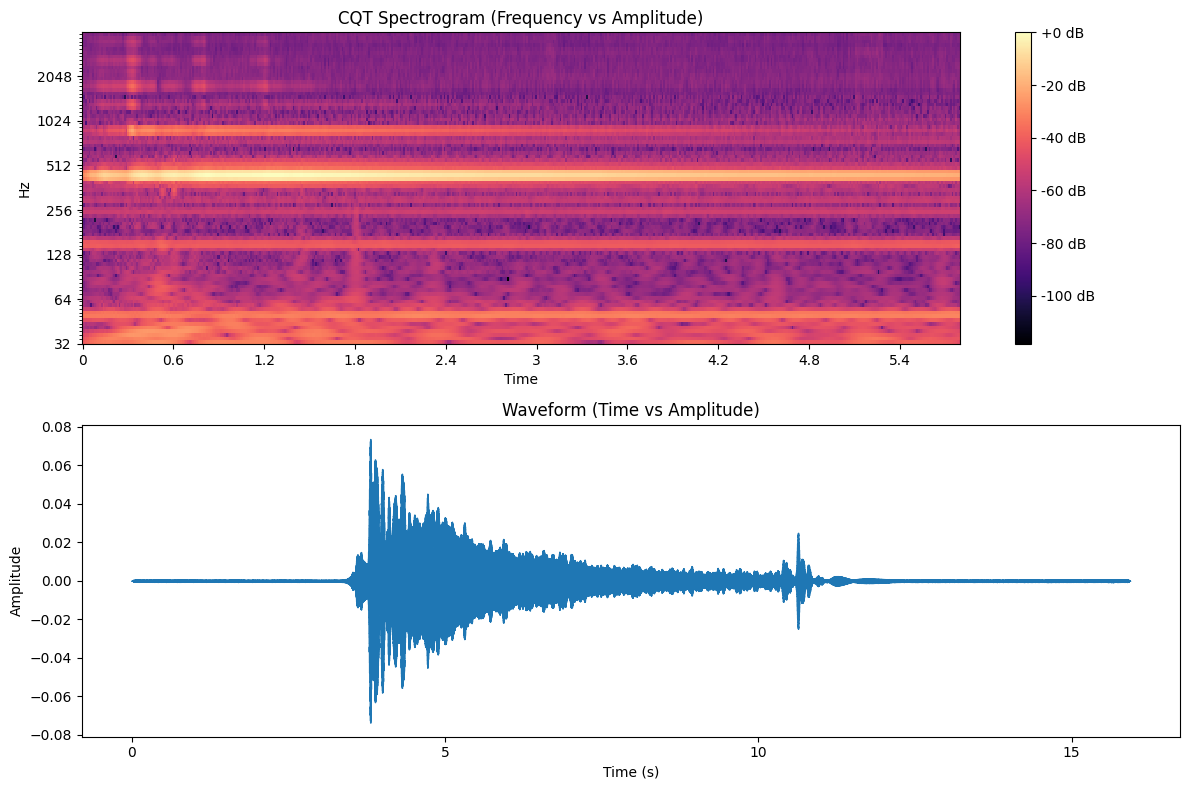

In [ ]:
#%----General Plotting-----$#
import librosa.display
import matplotlib.pyplot as plt

# Create subplots: CQT (freq vs amp) and waveform (time vs amp)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot CQT spectrogram (frequency vs amplitude)
img = librosa.display.specshow(amp_to_db(cqt, ref=np.max(cqt)), sr=sr, x_axis='time', y_axis='cqt_hz', ax=ax1)
ax1.set_title('CQT Spectrogram (Frequency vs Amplitude)')
fig.colorbar(img, ax=ax1, format='%+2.0f dB')

# Plot waveform (time vs amplitude)
librosa.display.waveshow(y, sr=sr, ax=ax2)
ax2.set_title('Waveform (Time vs Amplitude)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

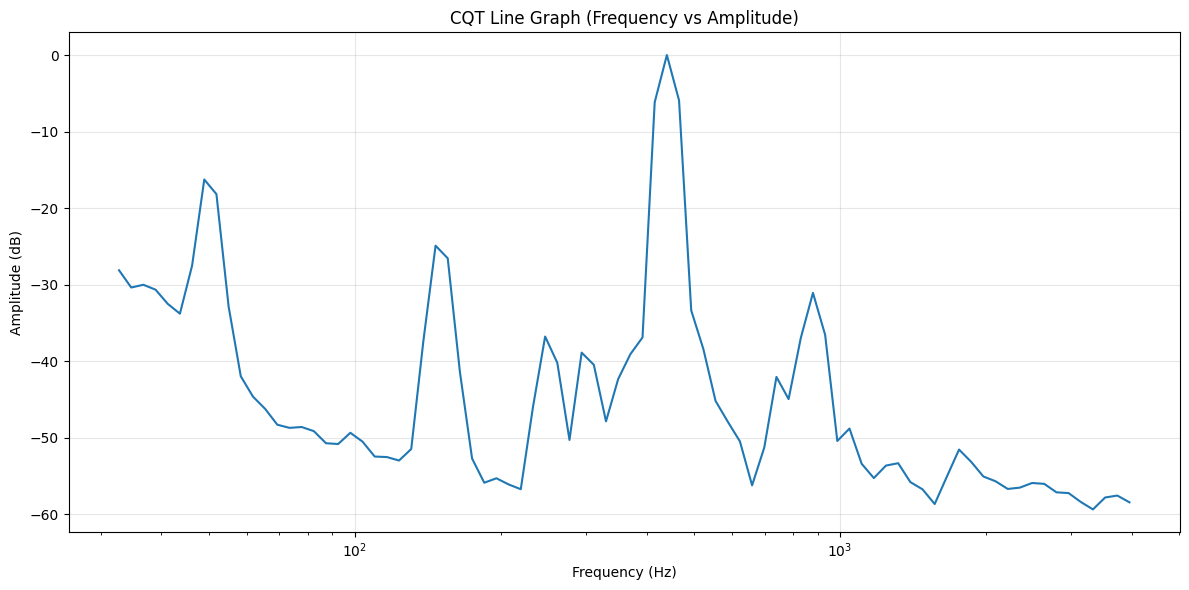

In [27]:
#%----CQT Line Graph
# Plot CQT as line graph (magnitude vs frequency)
fig, ax = plt.subplots(figsize=(12, 6))

# Average CQT magnitude across time to get overall frequency content
cqt_mag = np.abs(cqt)
cqt_mean = np.mean(cqt_mag, axis=1)

# Get frequency values for CQT bins
freqs = librosa.cqt_frequencies(n_bins=cqt.shape[0], fmin=librosa.note_to_hz('C1'), bins_per_octave=12)

# Plot as line graph
ax.plot(freqs, librosa.amplitude_to_db(cqt_mean, ref=np.max(cqt_mean)), linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude (dB)')
ax.set_title('CQT Line Graph (Frequency vs Amplitude)')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()